# Лабораторная работа E6 — Формирование признаков ЭМГ

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/biomenace/digital-signal-processing/blob/main/notebooks/e6.ipynb)

Ноутбук-спутник к интерактивной работе: **[открыть саму лабораторную](https://biomenace.github.io/digital-signal-processing/labs/e6.html)**.

**Что разбираем.** Классификатор не умеет работать с сырым сигналом: в окне
200 мс при 1000 Гц лежит 200 чисел на канал, и почти все они — шум. Поэтому
окно сначала сворачивают в короткий **вектор признаков** — несколько чисел,
которые описывают окно по существу.

Классический набор для ЭМГ предложил Хадгинс: **MAV, RMS, WL, ZC, SSC**.
Первые три про амплитуду («насколько сильно»), последние два про частоту
(«насколько быстро»). Добавим к ним **MDF** и **MNF** из лабы E2 — получится
7 признаков на канал, то есть 56 чисел на окно с восьмиканального браслета.

Главный вопрос лабы: **расходятся ли жесты в этом пространстве признаков?**
Если облака точек разных жестов перекрываются, никакой классификатор их не
разделит — и чинить надо признаки, а не классификатор.

In [1]:
# ЯЧЕЙКА 1 · Установка и импорты.
# Запусти один раз в начале работы и больше сюда не возвращайся.
# В Google Colab почти всё уже стоит, поэтому обычно ничего не скачивается.

import importlib.util
import subprocess
import sys


def ensure(packages):
    """Ставит только те пакеты, которых нет. packages: [(модуль, имя-для-pip)]."""
    missing = [pip for mod, pip in packages if not importlib.util.find_spec(mod)]
    if missing:
        print("Ставлю:", ", ".join(missing))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing],
                       check=True)
    print("Готово. Python", sys.version.split()[0])


ensure([("numpy", "numpy"), ("scipy", "scipy"), ("matplotlib", "matplotlib")])

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

%matplotlib inline
matplotlib.rcParams.update({
    "figure.figsize": (11, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.linewidth": 0.4,
    "axes.titlesize": 12,
    "font.size": 11,
})

Готово. Python 3.10.12


In [2]:
ensure([("sklearn", "scikit-learn")])

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler

Готово. Python 3.10.12


In [3]:
# ЯЧЕЙКА 2 · Признаки ЭМГ и нарезка на окна.
# Это «чёрный ящик» лабы: запусти один раз и дальше просто вызывай функции.
# Внутри — классический набор Хадгинса (Hudgins et al., 1993) плюс две
# частотные характеристики. Разбираться в реализации не нужно.

FS = 1000.0          # частота дискретизации записи, Гц
N_CH = 8             # каналов в браслете

TD_NAMES = ["MAV", "RMS", "WL", "ZC", "SSC"]
FREQ_NAMES = ["MDF", "MNF"]


def window_signal(X, y, fs=FS, win_ms=200.0, step_ms=100.0, keep=None, purity=0.6):
    """Режет запись X[N, C] с метками y[N] на скользящие окна.

    Метка окна — самый частый класс внутри него. Окно на стыке двух жестов
    (ни один класс не занимает purity доли окна) выбрасывается.
    Возвращает (windows[K, W, C], labels[K]).
    """
    width = int(round(win_ms / 1000.0 * fs))
    step = int(round(step_ms / 1000.0 * fs))
    keep = set(range(1, 8)) if keep is None else set(keep)
    wins, labs = [], []
    for start in range(0, len(X) - width + 1, step):
        chunk = y[start:start + width]
        values, counts = np.unique(chunk, return_counts=True)
        label = int(values[np.argmax(counts)])
        if label not in keep or counts.max() < purity * width:
            continue
        wins.append(X[start:start + width, :])
        labs.append(label)
    if not wins:
        return np.empty((0, width, X.shape[1])), np.empty((0,), int)
    return np.asarray(wins), np.asarray(labs, int)


def td_features(x, rel_eps=0.02):
    """Пять признаков Хадгинса по одному каналу.

    MAV — средний модуль (насколько сильно напряжена мышца);
    RMS — эффективная амплитуда (то же, что в лабе E4);
    WL  — суммарная длина кривой, мера «изрезанности»;
    ZC  — сколько раз сигнал пересёк ноль (грубая оценка частоты);
    SSC — сколько раз сменился знак наклона (тоже про частоту).

    ZC и SSC считают с мёртвой зоной rel_eps от уровня сигнала: без неё они
    считали бы дрожание нуля, а не настоящие колебания.
    """
    eps = rel_eps * np.sqrt(np.mean(x ** 2)) + 1e-12
    diff = np.diff(x)
    zc = int(np.sum((x[:-1] * x[1:] < 0) & (np.abs(diff) > eps)))
    d1, d2 = x[1:-1] - x[:-2], x[1:-1] - x[2:]
    ssc = int(np.sum((d1 * d2 > 0) & ((np.abs(d1) > eps) | (np.abs(d2) > eps))))
    return np.array([np.mean(np.abs(x)), np.sqrt(np.mean(x ** 2)),
                     np.sum(np.abs(diff)), zc, ssc], float)


def freq_features(x, fs=FS):
    """MDF и MNF — медианная и средняя частоты спектра мощности канала.

    MDF делит энергию спектра пополам, MNF — центр масс спектра. Обе падают
    при утомлении мышцы, поэтому их считают вместе с амплитудными.
    """
    x = x - np.mean(x)
    power = np.abs(np.fft.rfft(x * np.hanning(len(x)))) ** 2
    freqs = np.fft.rfftfreq(len(x), d=1.0 / fs)
    total = power.sum() + 1e-24
    cumulative = np.cumsum(power)
    mdf = freqs[np.searchsorted(cumulative, cumulative[-1] / 2)]
    return np.array([mdf, np.sum(freqs * power) / total], float)


def features_window(win, fs=FS):
    """Одно окно win[W, C] → один длинный вектор чисел: 7 признаков на канал."""
    return np.concatenate([
        np.concatenate([td_features(win[:, c]), freq_features(win[:, c], fs)])
        for c in range(win.shape[1])])


def feature_names(n_ch=N_CH):
    """Имена координат вектора признаков — в том же порядке, что и значения."""
    return ["ch%d_%s" % (c + 1, nm)
            for c in range(n_ch) for nm in TD_NAMES + FREQ_NAMES]


def features_of(X, y, fs=FS, win_ms=200.0, step_ms=100.0, keep=None):
    """Запись → матрица признаков. Возвращает (Xf[K, D], labels[K])."""
    wins, labs = window_signal(X, y, fs, win_ms, step_ms, keep)
    return np.array([features_window(w, fs) for w in wins]), labs

In [4]:
# ЯЧЕЙКА 3 · Данные: скачиваем настоящий датасет.
# Работаем не на выдумке, а на открытой записи UCI «EMG Data for Gestures»
# (Lobov et al., 2018): 36 человек, браслет MYO — восемь электродов по
# окружности предплечья, по две серии на человека, размеченные жесты.
# Архив ~17 МБ, качается один раз за сессию. Ничего ставить руками не нужно.

import os
import glob
import urllib.request
import zipfile

DATA_URL = "https://archive.ics.uci.edu/static/public/481/emg+data+for+gestures.zip"
DATA_DIR = "EMG_data_for_gestures-master"

GESTURE_NAMES = {
    0: "неразмечено", 1: "покой", 2: "кулак", 3: "сгибание",
    4: "разгибание", 5: "радиальное", 6: "локтевое", 7: "ладонь",
}


def fetch_dataset(url=DATA_URL, directory=DATA_DIR):
    """Скачивает и распаковывает датасет. Повторный вызов ничего не делает."""
    # Печатаем только имя папки, без полного пути: путь на чужой машине
    # читателю ничего не говорит, а в сохранённом выводе ноутбука остаётся.
    directory = os.environ.get("EMG_DATA_DIR", directory)
    name = os.path.basename(directory.rstrip("/\\")) or directory
    if os.path.isdir(directory):
        print("Датасет уже на месте:", name)
        return directory
    print("Скачиваю архив (~17 МБ)...")
    archive, _ = urllib.request.urlretrieve(url)
    with zipfile.ZipFile(archive) as zf:
        zf.extractall(".")
    os.remove(archive)
    print("Готово:", name)
    return directory


def list_subjects(directory=DATA_DIR):
    """Номера доступных испытуемых: '01', '02', ... '36'."""
    return sorted(d for d in os.listdir(directory)
                  if d.isdigit() and os.path.isdir(os.path.join(directory, d)))


def subject_files(subject, directory=DATA_DIR):
    """Файлы одного человека — обычно две серии, записанные подряд."""
    pattern = os.path.join(directory, str(subject).zfill(2), "*_raw_data_*.txt")
    return sorted(glob.glob(pattern))


def load_record(path):
    """Один файл записи → (X[N, 8], y[N]).

    В файле десять столбцов: время в мс, восемь каналов и метка жеста.
    Шаг времени 1 мс, отсюда FS = 1000 Гц. Метка 0 — участок без разметки.
    Каналы переводим из вольт в милливольты, иначе все числа выглядят как
    0.00002 и читать их невозможно.
    """
    data = np.loadtxt(path, skiprows=1)
    return data[:, 1:9] * 1000.0, data[:, 9].astype(int)


def plot_record(X, y, fs=FS, seconds=12.0, channels=(0, 2, 4, 6)):
    """Кусок записи: как выглядят каналы и где какой жест был размечен."""
    n = min(len(X), int(seconds * fs))
    t = np.arange(n) / fs
    present = sorted(set(int(v) for v in np.unique(y[:n])))
    fig, axes = plt.subplots(len(channels) + 1, 1, sharex=True,
                             figsize=(12, 1.4 * len(channels) + 2.4))
    for ax, c in zip(axes, channels):
        ax.plot(t, X[:n, c], lw=0.6, color="steelblue")
        ax.set_ylabel("кан. %d" % (c + 1))
    axes[-1].step(t, y[:n], where="post", color="darkorange", lw=1.6)
    axes[-1].set(xlabel="$t$, с", ylabel="жест", yticks=present)
    axes[-1].set_yticklabels([GESTURE_NAMES[v] for v in present])
    axes[0].set_title("Запись браслета MYO: четыре канала из восьми и разметка жестов")
    fig.tight_layout()
    plt.show()


def class_table(y, title="Распределение по классам"):
    """Сколько окон (или отсчётов) пришлось на каждый класс."""
    values, counts = np.unique(y, return_counts=True)
    print(title + ":")
    for v, c in zip(values, counts):
        print("   %-12s %6d" % (GESTURE_NAMES[int(v)], c))

## Ячейка 4 · Берём одну запись и смотрим, что в ней

Скачиваем датасет и открываем первую серию первого испытуемого.

Датасет уже на месте: EMG_data_for_gestures-master
Файлов у испытуемого 01: 2
Отсчётов: 63196 (63 с записи), каналов: 8
Отсчётов на класс:
   неразмечено   41272
   покой          3780
   кулак          3525
   сгибание       3816
   разгибание     3441
   радиальное     3615
   локтевое       3747


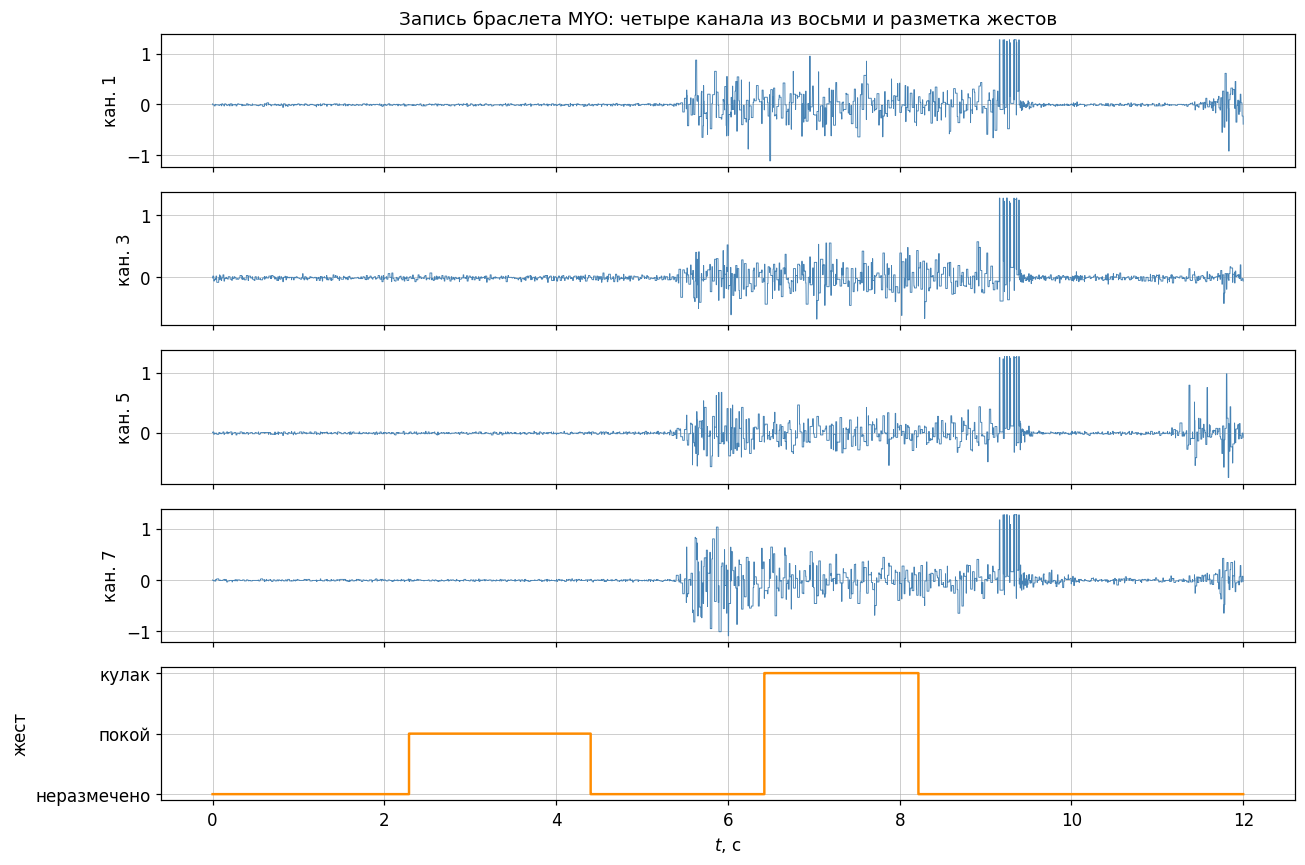

In [5]:
root = fetch_dataset()
files = subject_files("01", root)
print("Файлов у испытуемого 01:", len(files))

X, y = load_record(files[0])
print("Отсчётов: %d (%.0f с записи), каналов: %d" % (len(X), len(X) / FS, X.shape[1]))
class_table(y, "Отсчётов на класс")

plot_record(X, y)

Метка `неразмечено` — это паузы между заданиями; такие участки в работу не
берём. Видно и главное свойство ЭМГ: разные жесты поднимают разные каналы, но
на глаз по одному каналу их не различить.

## Ячейка 5 · Режем на окна и считаем признаки

Меняй `WIN_MS` и `STEP_MS` — это те же ползунки, что в браузерной версии.

In [6]:
WIN_MS = 200.0                  # длина окна, мс
STEP_MS = 50.0                  # шаг между окнами, мс
GESTURES = [1, 2, 3, 4]         # покой, кулак, сгибание, разгибание

Xf, labels = features_of(X, y, FS, WIN_MS, STEP_MS, keep=GESTURES)
names = feature_names(X.shape[1])

print("Окон: %d, длина вектора признаков: %d = %d каналов × %d признака"
      % (len(labels), Xf.shape[1], X.shape[1], len(TD_NAMES) + len(FREQ_NAMES)))
class_table(labels, "\nОкон на класс")

print("\nВектор признаков окна №0, первые 7 чисел (это весь канал 1):")
for name, value in list(zip(names, Xf[0]))[:7]:
    print("   %-10s = %10.5f" % (name, value))

Окон: 285, длина вектора признаков: 56 = 8 каналов × 7 признака

Окон на класс:
   покой            73
   кулак            69
   сгибание         75
   разгибание       68

Вектор признаков окна №0, первые 7 чисел (это весь канал 1):
   ch1_MAV    =    0.01435
   ch1_RMS    =    0.01657
   ch1_WL     =    0.20000
   ch1_ZC     =    2.00000
   ch1_SSC    =    2.00000
   ch1_MDF    =   25.00000
   ch1_MNF    =   54.55126


## Ячейка 6 · Как признак меняется от жеста к жесту

Возьмём один признак — MAV, среднюю амплитуду — и посмотрим его по всем
восьми каналам для каждого жеста. Это и есть «портрет» жеста: не одно число,
а рисунок распределения силы по окружности предплечья.

покой         0.0126  0.0220  0.0284  0.0161  0.0124  0.0117  0.0111  0.0112
кулак         0.1698  0.0868  0.1514  0.1204  0.1241  0.1608  0.1909  0.1228
сгибание      0.1409  0.1724  0.0601  0.0520  0.1131  0.0732  0.0583  0.1258
разгибание    0.0399  0.0628  0.0920  0.1838  0.3080  0.2002  0.0846  0.0557


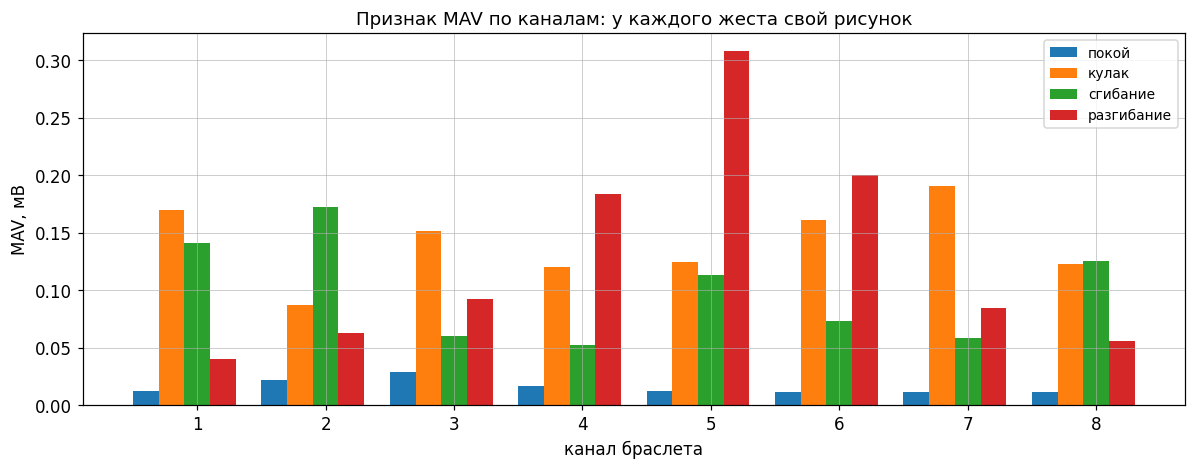

In [7]:
FEATURE = "MAV"                 # попробуй также RMS, WL, ZC, SSC, MDF, MNF

columns = [i for i, name in enumerate(names) if name.endswith("_" + FEATURE)]
channels = np.arange(1, len(columns) + 1)

fig, ax = plt.subplots(figsize=(11, 4.4))
width = 0.8 / len(GESTURES)
for k, gesture in enumerate(GESTURES):
    profile = Xf[labels == gesture][:, columns].mean(axis=0)
    ax.bar(channels + (k - len(GESTURES) / 2) * width, profile, width,
           label=GESTURE_NAMES[gesture])
    print("%-12s %s" % (GESTURE_NAMES[gesture],
                        " ".join("%7.4f" % v for v in profile)))
ax.set(xlabel="канал браслета", ylabel=FEATURE + ", мВ", xticks=channels,
       title="Признак %s по каналам: у каждого жеста свой рисунок" % FEATURE)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## Ячейка 7 · Разделимость: расходятся ли жесты в пространстве признаков

56 измерений глазами не увидеть, поэтому сожмём их до двух методом LDA — он
ищет те направления, вдоль которых классы расходятся сильнее всего. Если и
после такого сжатия облака перемешаны, признаки жест не описывают.

Числовая мера того же: **индекс разделимости** — среднее расстояние между
центрами классов, делённое на средний разброс внутри класса.

Между классами: 9.62 | внутри класса: 1.23 | индекс разделимости: 7.84
Ориентир: индекс больше ~1.2 — облака расходятся, жесты различимы.
Важно: LDA подобран по этим же окнам, поэтому картинка приукрашена.
Честную оценку даёт проверка на отдельной записи — это лабораторная E8.


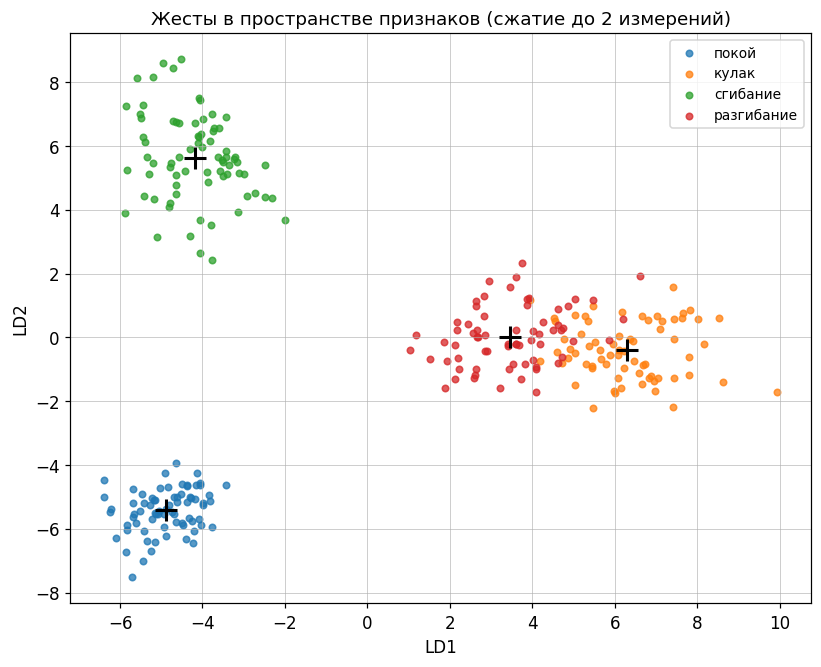

In [8]:
projected = LinearDiscriminantAnalysis(n_components=2).fit_transform(
    StandardScaler().fit_transform(Xf), labels)

centers = {g: projected[labels == g].mean(axis=0) for g in GESTURES}
inside = np.mean([np.linalg.norm(projected[i] - centers[labels[i]])
                  for i in range(len(labels))])
pairs = [np.linalg.norm(centers[a] - centers[b])
         for i, a in enumerate(GESTURES) for b in GESTURES[i + 1:]]
index = np.mean(pairs) / (inside + 1e-9)

print("Между классами: %.2f | внутри класса: %.2f | индекс разделимости: %.2f"
      % (np.mean(pairs), inside, index))
print("Ориентир: индекс больше ~1.2 — облака расходятся, жесты различимы.")
print("Важно: LDA подобран по этим же окнам, поэтому картинка приукрашена.")
print("Честную оценку даёт проверка на отдельной записи — это лабораторная E8.")

fig, ax = plt.subplots(figsize=(7.6, 6.2))
for gesture in GESTURES:
    mask = labels == gesture
    ax.scatter(projected[mask, 0], projected[mask, 1], s=18, alpha=0.75,
               label=GESTURE_NAMES[gesture])
for gesture, center in centers.items():
    ax.plot(center[0], center[1], "k+", ms=14, mew=2)
ax.set(xlabel="LD1", ylabel="LD2",
       title="Жесты в пространстве признаков (сжатие до 2 измерений)")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

Крестики — центры классов. Чем дальше они друг от друга и чем плотнее вокруг
них облака, тем проще будет классификатору в лабе E7.

## Задания

1. Для своего набора жестов из таблицы вариантов запиши индекс разделимости и
   приложи scatter. Какие два жеста перекрываются сильнее всего?
2. Прогони длину окна 50, 100, 200 и 400 мс. Построй зависимость индекса
   разделимости от длины окна и объясни, почему у короткого окна он ниже.
3. Оставь только пять признаков Хадгинса (убери MDF и MNF из `features_window`)
   и сравни индекс. Насколько частотные признаки вообще что-то добавляют?